In [ ]:
!pip install scipy networkx matplotlib


# New Section

In [ ]:
import scipy.io
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
file_path = '/content/Adjacency matrix.mat'  # Update with the uploaded file path
mat_data = scipy.io.loadmat(file_path)

In [ ]:
print(mat_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'A', 'ROInames'])


In [ ]:
adj_matrix = mat_data['A']  # Adjacency matrix
roi_names = mat_data['ROInames']

In [ ]:
adj_matrix_2d = adj_matrix[:, :, 0]

In [ ]:
G = nx.from_numpy_array(adj_matrix_2d)

In [ ]:
G = nx.relabel_nodes(G, {i: str(roi_names[i][0]) for i in range(len(roi_names))})

In [ ]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 164
Number of edges: 2005


In [ ]:
print("Nodes:", list(G.nodes))

Nodes: ["['networks.DefaultMode.MPFC (1,55,-3)']", 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163]


In [ ]:
print("Edges:", list(G.edges))

Edges: [("['networks.DefaultMode.MPFC (1,55,-3)']", 1), ("['networks.DefaultMode.MPFC (1,55,-3)']", 2), ("['networks.DefaultMode.MPFC (1,55,-3)']", 3), ("['networks.DefaultMode.MPFC (1,55,-3)']", 32), ("['networks.DefaultMode.MPFC (1,55,-3)']", 46), ("['networks.DefaultMode.MPFC (1,55,-3)']", 52), ("['networks.DefaultMode.MPFC (1,55,-3)']", 53), ("['networks.DefaultMode.MPFC (1,55,-3)']", 54), ("['networks.DefaultMode.MPFC (1,55,-3)']", 55), ("['networks.DefaultMode.MPFC (1,55,-3)']", 80), ("['networks.DefaultMode.MPFC (1,55,-3)']", 83), ("['networks.DefaultMode.MPFC (1,55,-3)']", 84), ("['networks.DefaultMode.MPFC (1,55,-3)']", 85), ("['networks.DefaultMode.MPFC (1,55,-3)']", 86), ("['networks.DefaultMode.MPFC (1,55,-3)']", 87), ("['networks.DefaultMode.MPFC (1,55,-3)']", 88), ("['networks.DefaultMode.MPFC (1,55,-3)']", 91), ("['networks.DefaultMode.MPFC (1,55,-3)']", 92), ("['networks.DefaultMode.MPFC (1,55,-3)']", 95), ("['networks.DefaultMode.MPFC (1,55,-3)']", 123), ("['networks.D

In [ ]:
# Iterate through edges with weights (if any)
for edge in G.edges(data=True):
    print(edge)


("['networks.DefaultMode.MPFC (1,55,-3)']", 1, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 2, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 3, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 32, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 46, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 52, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 53, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 54, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 55, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 80, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 83, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 84, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 85, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 86, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 87, {'weight': 1})
("['networks.DefaultMode.MPFC (1,55,-3)']", 88, {'weight':

In [ ]:
# Save nodes to a file
with open("nodes.txt", "w") as f:
    for node in nodes:
        f.write(f"{node}\n")

# Save edges to a file
with open("edges.txt", "w") as f:
    # Get the edges from the graph G
    edges = G.edges() # Assign the edges of the graph G to the variable 'edges'
    for edge in edges:
        f.write(f"{edge[0]} {edge[1]}\n")

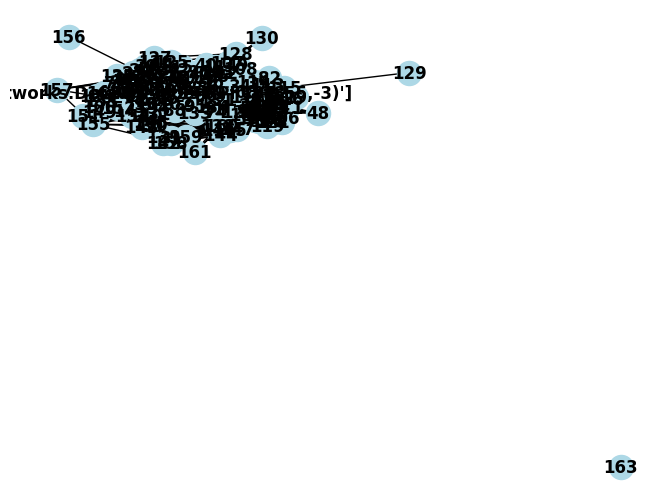

In [ ]:
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', font_weight='bold')
plt.show()

In [ ]:
# Basic properties
print("Graph Density:", nx.density(G))
print("Is the graph connected?", nx.is_connected(G))

# Degree of each node
degrees = dict(G.degree())
print("Node Degrees:", degrees)

# Average degree
average_degree = sum(degrees.values()) / len(degrees)
print("Average Degree:", average_degree)


Graph Density: 0.1500074816699087
Is the graph connected? False
Node Degrees: {"['networks.DefaultMode.MPFC (1,55,-3)']": 28, 1: 34, 2: 27, 3: 23, 4: 48, 5: 51, 6: 45, 7: 43, 8: 32, 9: 46, 10: 45, 11: 22, 12: 30, 13: 24, 14: 18, 15: 19, 16: 22, 17: 14, 18: 13, 19: 13, 20: 33, 21: 27, 22: 21, 23: 24, 24: 24, 25: 24, 26: 20, 27: 25, 28: 11, 29: 24, 30: 21, 31: 11, 32: 34, 33: 33, 34: 37, 35: 25, 36: 20, 37: 19, 38: 29, 39: 17, 40: 21, 41: 21, 42: 29, 43: 26, 44: 48, 45: 45, 46: 30, 47: 32, 48: 7, 49: 5, 50: 22, 51: 12, 52: 25, 53: 15, 54: 32, 55: 32, 56: 23, 57: 21, 58: 16, 59: 15, 60: 32, 61: 24, 62: 31, 63: 20, 64: 44, 65: 44, 66: 35, 67: 32, 68: 31, 69: 19, 70: 29, 71: 22, 72: 25, 73: 27, 74: 37, 75: 30, 76: 42, 77: 42, 78: 38, 79: 37, 80: 28, 81: 30, 82: 13, 83: 29, 84: 30, 85: 28, 86: 31, 87: 32, 88: 24, 89: 39, 90: 46, 91: 37, 92: 31, 93: 13, 94: 21, 95: 11, 96: 6, 97: 42, 98: 42, 99: 19, 100: 7, 101: 23, 102: 17, 103: 42, 104: 41, 105: 42, 106: 37, 107: 16, 108: 18, 109: 45, 110: 

In [ ]:
# Betweenness Centrality
betweenness = nx.betweenness_centrality(G)
print("Betweenness Centrality:", betweenness)

# Closeness Centrality
closeness = nx.closeness_centrality(G)
print("Closeness Centrality:", closeness)

# Eigenvector Centrality
eigenvector = nx.eigenvector_centrality(G)
print("Eigenvector Centrality:", eigenvector)




Betweenness Centrality: {"['networks.DefaultMode.MPFC (1,55,-3)']": 0.010589180529445522, 1: 0.021383580442169016, 2: 0.008385445986516008, 3: 0.009988199498977618, 4: 0.010775528327181675, 5: 0.019282559224770936, 6: 0.009568171971822888, 7: 0.004933060304615497, 8: 0.0008612485128311669, 9: 0.009897474649365839, 10: 0.007818140974931376, 11: 0.003619665313675354, 12: 0.011960843472777807, 13: 0.004867346053007576, 14: 0.0016940877053379564, 15: 0.003361177524263794, 16: 0.009675988715991266, 17: 0.0015307480306100726, 18: 0.0017314098494153548, 19: 0.00035319649480986974, 20: 0.005112241550118832, 21: 0.011298570894463296, 22: 0.003894176318240804, 23: 0.0059369612893537, 24: 0.004214899367886679, 25: 0.002870122729781855, 26: 0.003507685390593195, 27: 0.0064047945648398824, 28: 0.0022635250763799013, 29: 0.010200289081006479, 30: 0.013288445453668363, 31: 0.00019124303382498644, 32: 0.015074347082131552, 33: 0.009291708395198188, 34: 0.019634685518360773, 35: 0.005983091980130338, 3

In [ ]:
# Average clustering coefficient
avg_clustering = nx.average_clustering(G)
print("Average Clustering Coefficient:", avg_clustering)

# Clustering coefficient of each node
clustering = nx.clustering(G)
print("Clustering Coefficients:", clustering)


Average Clustering Coefficient: 0.5122076455468418
Clustering Coefficients: {"['networks.DefaultMode.MPFC (1,55,-3)']": 0.4497354497354497, 1: 0.35472370766488415, 2: 0.45584045584045585, 3: 0.3952569169960474, 4: 0.5904255319148937, 5: 0.5419607843137255, 6: 0.6535353535353535, 7: 0.7242524916943521, 8: 0.8790322580645161, 9: 0.6502415458937199, 10: 0.6727272727272727, 11: 0.5108225108225108, 12: 0.4091954022988506, 13: 0.4673913043478261, 14: 0.5686274509803921, 15: 0.49122807017543857, 16: 0.3463203463203463, 17: 0.5604395604395604, 18: 0.6794871794871795, 19: 0.8205128205128205, 20: 0.696969696969697, 21: 0.47293447293447294, 22: 0.5523809523809524, 23: 0.5, 24: 0.4891304347826087, 25: 0.5579710144927537, 26: 0.5210526315789473, 27: 0.5266666666666666, 28: 0.34545454545454546, 29: 0.34782608695652173, 30: 0.40476190476190477, 31: 0.8909090909090909, 32: 0.39037433155080214, 33: 0.4128787878787879, 34: 0.4114114114114114, 35: 0.53, 36: 0.3263157894736842, 37: 0.45614035087719296, 38

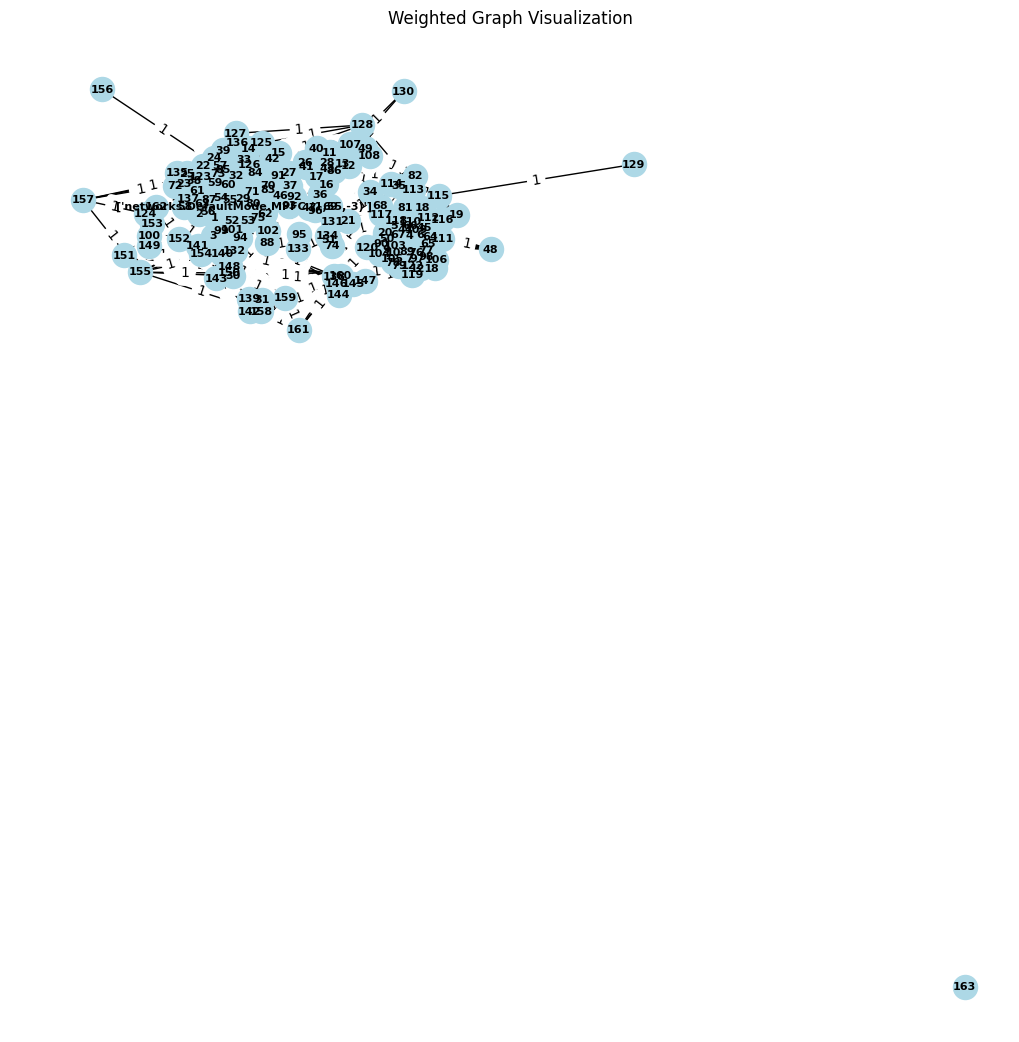

In [ ]:
# Add edge weights for visualization
edge_weights = nx.get_edge_attributes(G, 'weight')
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_color='lightblue', font_weight='bold', node_size=300, font_size=8)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_weights)
plt.title("Weighted Graph Visualization")
plt.show()


In [ ]:
# Get all nodes
nodes = list(G.nodes())
print("Nodes in the graph:", nodes)


Nodes in the graph: ["['networks.DefaultMode.MPFC (1,55,-3)']", 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163]


In [ ]:
# Get node attributes
node_attrs = nx.get_node_attributes(G, 'attribute_name')  # Replace 'attribute_name' with the actual attribute
print("Node attributes:", node_attrs)


Node attributes: {}


In [ ]:
# Print all node labels
print("Node labels:", [str(roi_names[i][0]) for i in range(len(roi_names))])


Node labels: ["['networks.DefaultMode.MPFC (1,55,-3)']"]


In [ ]:
# Number of nodes
num_nodes = G.number_of_nodes()
print("Number of nodes:", num_nodes)


Number of nodes: 164


In [ ]:
# Degrees of all nodes
node_degrees = dict(G.degree())
print("Node degrees:", node_degrees)


Node degrees: {"['networks.DefaultMode.MPFC (1,55,-3)']": 28, 1: 34, 2: 27, 3: 23, 4: 48, 5: 51, 6: 45, 7: 43, 8: 32, 9: 46, 10: 45, 11: 22, 12: 30, 13: 24, 14: 18, 15: 19, 16: 22, 17: 14, 18: 13, 19: 13, 20: 33, 21: 27, 22: 21, 23: 24, 24: 24, 25: 24, 26: 20, 27: 25, 28: 11, 29: 24, 30: 21, 31: 11, 32: 34, 33: 33, 34: 37, 35: 25, 36: 20, 37: 19, 38: 29, 39: 17, 40: 21, 41: 21, 42: 29, 43: 26, 44: 48, 45: 45, 46: 30, 47: 32, 48: 7, 49: 5, 50: 22, 51: 12, 52: 25, 53: 15, 54: 32, 55: 32, 56: 23, 57: 21, 58: 16, 59: 15, 60: 32, 61: 24, 62: 31, 63: 20, 64: 44, 65: 44, 66: 35, 67: 32, 68: 31, 69: 19, 70: 29, 71: 22, 72: 25, 73: 27, 74: 37, 75: 30, 76: 42, 77: 42, 78: 38, 79: 37, 80: 28, 81: 30, 82: 13, 83: 29, 84: 30, 85: 28, 86: 31, 87: 32, 88: 24, 89: 39, 90: 46, 91: 37, 92: 31, 93: 13, 94: 21, 95: 11, 96: 6, 97: 42, 98: 42, 99: 19, 100: 7, 101: 23, 102: 17, 103: 42, 104: 41, 105: 42, 106: 37, 107: 16, 108: 18, 109: 45, 110: 40, 111: 39, 112: 29, 113: 19, 114: 19, 115: 24, 116: 27, 117: 3

In [ ]:
# Neighbors of a node
specific_node = nodes[6]  # Replace with the node of interest
neighbors = list(G.neighbors(specific_node))
print(f"Neighbors of node {specific_node}:", neighbors)


Neighbors of node 6: [4, 5, 7, 8, 9, 10, 18, 19, 20, 21, 36, 37, 44, 45, 64, 65, 66, 67, 68, 74, 76, 77, 78, 79, 81, 82, 89, 90, 97, 98, 103, 104, 105, 106, 109, 110, 111, 112, 116, 117, 118, 119, 120, 121, 122]


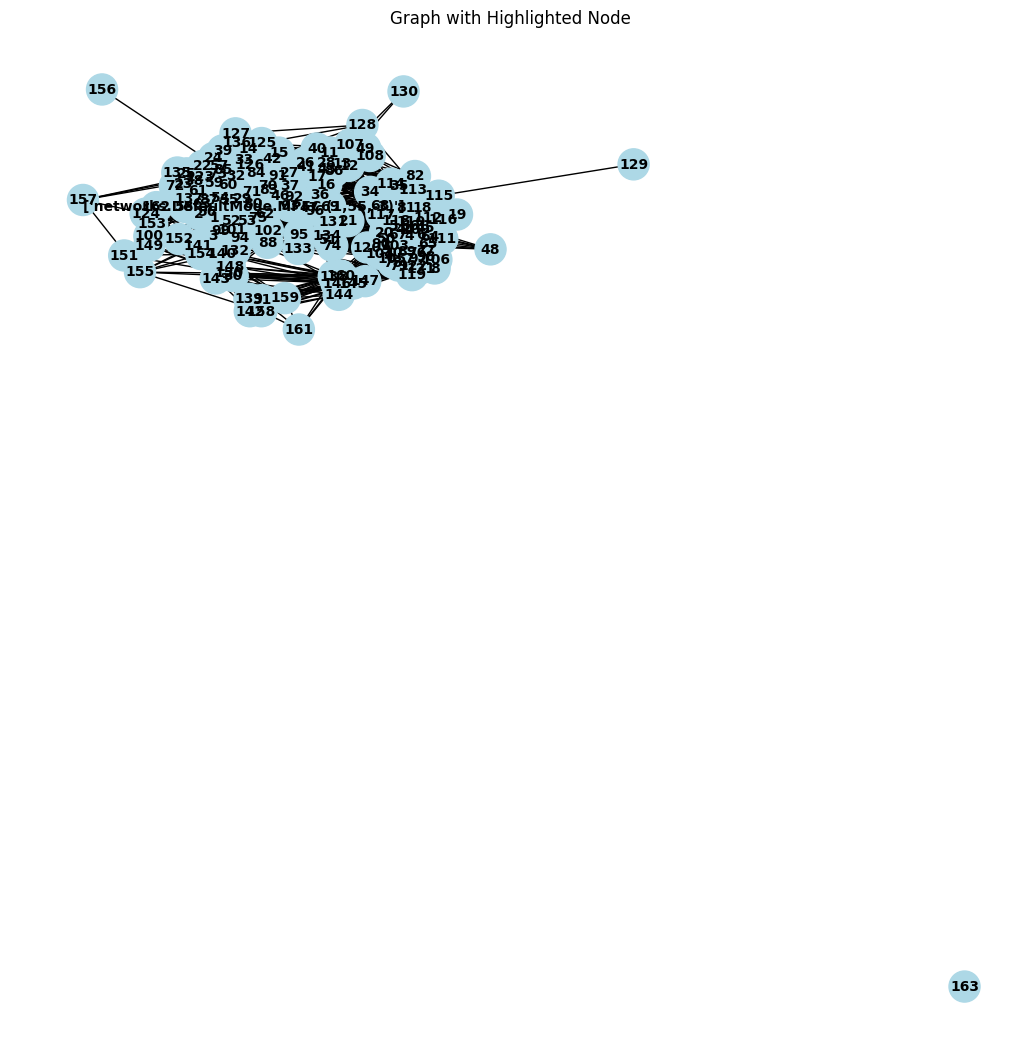

In [ ]:
# Highlight a specific node
specific_node = nodes[6]  # Replace with the node of interest
node_colors = ['red' if node == specific_node else 'lightblue' for node in G.nodes()]

plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_color=node_colors, font_weight='bold', node_size=500, font_size=10)
plt.title("Graph with Highlighted Node")
plt.show()


In [ ]:
# Filter nodes with a degree greater than a threshold
threshold = 5
filtered_nodes = [node for node, degree in G.degree() if degree > threshold]
print(f"Nodes with degree greater than {threshold}:", filtered_nodes)


Nodes with degree greater than 5: ["['networks.DefaultMode.MPFC (1,55,-3)']", 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 158, 159, 160, 161, 162]


In [ ]:
# Print the ROI names to understand their structure
print(roi_names)
print("Shape of ROInames:", roi_names.shape)


[[array(['networks.DefaultMode.MPFC (1,55,-3)'], dtype='<U35')
  array(['networks.DefaultMode.LP (L) (-39,-77,33)'], dtype='<U40')
  array(['networks.DefaultMode.LP (R) (47,-67,29)'], dtype='<U39')
  array(['networks.DefaultMode.PCC (1,-61,38)'], dtype='<U35')
  array(['networks.SensoriMotor.Lateral (L) (-55,-12,29)'], dtype='<U46')
  array(['networks.SensoriMotor.Lateral (R) (56,-10,29)'], dtype='<U45')
  array(['networks.SensoriMotor.Superior  (0,-31,67)'], dtype='<U42')
  array(['networks.Visual.Medial (2,-79,12)'], dtype='<U33')
  array(['networks.Visual.Occipital (0,-93,-4)'], dtype='<U36')
  array(['networks.Visual.Lateral (L) (-37,-79,10)'], dtype='<U40')
  array(['networks.Visual.Lateral (R) (38,-72,13)'], dtype='<U39')
  array(['networks.Salience.ACC (0,22,35)'], dtype='<U31')
  array(['networks.Salience.AInsula (L) (-44,13,1)'], dtype='<U40')
  array(['networks.Salience.AInsula (R) (47,14,0)'], dtype='<U39')
  array(['networks.Salience.RPFC (L) (-32,45,27)'], dtype='<U38')
  

In [ ]:
print("Adjacency Matrix Shape:", adj_matrix.shape)
print("ROI Names:", roi_names[:5])

Adjacency Matrix Shape: (164, 164, 13)
ROI Names: [[array(['networks.DefaultMode.MPFC (1,55,-3)'], dtype='<U35')
  array(['networks.DefaultMode.LP (L) (-39,-77,33)'], dtype='<U40')
  array(['networks.DefaultMode.LP (R) (47,-67,29)'], dtype='<U39')
  array(['networks.DefaultMode.PCC (1,-61,38)'], dtype='<U35')
  array(['networks.SensoriMotor.Lateral (L) (-55,-12,29)'], dtype='<U46')
  array(['networks.SensoriMotor.Lateral (R) (56,-10,29)'], dtype='<U45')
  array(['networks.SensoriMotor.Superior  (0,-31,67)'], dtype='<U42')
  array(['networks.Visual.Medial (2,-79,12)'], dtype='<U33')
  array(['networks.Visual.Occipital (0,-93,-4)'], dtype='<U36')
  array(['networks.Visual.Lateral (L) (-37,-79,10)'], dtype='<U40')
  array(['networks.Visual.Lateral (R) (38,-72,13)'], dtype='<U39')
  array(['networks.Salience.ACC (0,22,35)'], dtype='<U31')
  array(['networks.Salience.AInsula (L) (-44,13,1)'], dtype='<U40')
  array(['networks.Salience.AInsula (R) (47,14,0)'], dtype='<U39')
  array(['networks

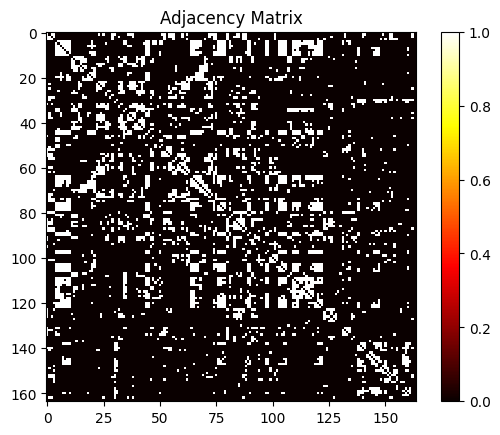

In [ ]:
plt.imshow(adj_matrix[:, :, 0], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title("Adjacency Matrix")
plt.show()

In [ ]:
import numpy as np

# Define a threshold for significant connections
threshold = 0.5  # Modify based on your data scale
significant_connections = np.argwhere(adj_matrix > threshold)

# Map ROI names to connections
for conn in significant_connections:
    # roi_names has shape (1, 164), so we need to access elements using roi_names[0, index]
    roi1 = roi_names[0, conn[0]][0]  # Accessing the correct element now
    roi2 = roi_names[0, conn[1]][0]  # Accessing the correct element now
    weight = adj_matrix[conn[0], conn[1]]
    print(f"Connection: {roi1} -> {roi2}, Weight: {weight}")

Streaming output truncated to the last 5000 lines.
Connection: atlas.Amygdala r -> networks.Salience.ACC (0,22,35), Weight: [0 0 0 0 0 0 0 0 0 0 0 1 0]
Connection: atlas.Amygdala r -> networks.Salience.RPFC (L) (-32,45,27), Weight: [0 0 0 0 0 0 0 0 0 0 0 1 0]
Connection: atlas.Amygdala r -> networks.Salience.RPFC (R) (32,46,27), Weight: [0 0 0 0 0 0 0 0 0 0 0 1 0]
Connection: atlas.Amygdala r -> networks.Salience.SMG (L) (-60,-39,31), Weight: [0 0 0 0 0 0 0 0 0 0 0 1 0]
Connection: atlas.Amygdala r -> networks.Salience.SMG (R) (62,-35,32), Weight: [0 0 0 0 0 0 0 0 0 0 0 1 0]
Connection: atlas.Amygdala r -> networks.DorsalAttention.IPS (L)  (-39,-43,52), Weight: [0 0 0 0 0 0 0 0 0 0 0 1 0]
Connection: atlas.Amygdala r -> networks.DorsalAttention.IPS (R)  (39,-42,54), Weight: [0 0 0 0 0 0 0 0 0 0 0 1 0]
Connection: atlas.Amygdala r -> networks.Language.pSTG (L) (-57,-47,15), Weight: [0 0 0 0 0 0 1 0 0 0 0 0 0]
Connection: atlas.Amygdala r -> networks.Language.pSTG (R) (59,-42,13), Weight

In [ ]:
# Calculate the average shortest path length for each connected component separately.
# Then, perhaps you can average the results or choose a representative component.

# Get connected components
connected_components = list(nx.connected_components(G))

# Calculate average path length for each component
avg_path_lengths = []
for component in connected_components:
    subgraph = G.subgraph(component)
    avg_path_lengths.append(nx.average_shortest_path_length(subgraph))

# Print or process the results as needed
print("Average path lengths for each component:", avg_path_lengths)

# Example: Calculate overall average
overall_avg_path_length = np.mean(avg_path_lengths)
print("Overall average path length:", overall_avg_path_length)

Average path lengths for each component: [2.2207074149814434, 0]
Overall average path length: 1.1103537074907217


In [ ]:
# Degree centrality (Hubs)
degree_centrality = nx.degree_centrality(G)
sorted_hubs = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Hubs by Degree Centrality:", sorted_hubs)

# PageRank
pagerank = nx.pagerank(G)
sorted_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Nodes by PageRank:", sorted_pagerank)

# Compute rich-club coefficient
rich_club_coef = nx.rich_club_coefficient(G, normalized=True)
print("Rich Club Coefficient:", rich_club_coef)

avg_clustering = nx.average_clustering(G)
print("Average Clustering Coefficient:", avg_clustering)


Top 10 Hubs by Degree Centrality: [(5, 0.3128834355828221), (4, 0.294478527607362), (44, 0.294478527607362), (120, 0.2883435582822086), (9, 0.2822085889570552), (90, 0.2822085889570552), (6, 0.27607361963190186), (10, 0.27607361963190186), (45, 0.27607361963190186), (109, 0.27607361963190186)]
Top 10 Nodes by PageRank: [(5, 0.0105088612728018), (4, 0.009884255367528152), (44, 0.009841952038905748), (120, 0.009604176676698837), (91, 0.00958078333321834), (9, 0.009305387781003408), (90, 0.009302807094423615), (45, 0.009183808435703227), (109, 0.009152300899004817), (6, 0.009148715383040757)]
Rich Club Coefficient: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0010330578512396, 8: 1.0015625, 9: 1.0015625, 10: 1.004230565838181, 11: 1.0060606060606059, 12: 1.0066555740432612, 13: 1.009253903990746, 14: 1.0125298329355608, 15: 1.0165542611894545, 16: 1.0203432930705658, 17: 1.0255737704918033, 18: 1.0321697467488022, 19: 1.0419426048565121, 20: 1.0590520590520591, 21: 1.0880

In [ ]:
# ROBUSTNESS ANALYSIS

# Remove a high-degree node and check connectivity
G_removed = G.copy()
high_degree_node = max(degree_centrality, key=degree_centrality.get)
G_removed.remove_node(high_degree_node)

is_connected_after_removal = nx.is_connected(G_removed)
print(f"Is the graph connected after removing {high_degree_node}? {is_connected_after_removal}")


Is the graph connected after removing 5? False


In [ ]:
# Identifying Functional or Critical Nodes
# Degree Centrality
degree_centrality = nx.degree_centrality(G)
top_degree_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Nodes by Degree Centrality:", top_degree_nodes)

# Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G)
top_betweenness_nodes = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Nodes by Betweenness Centrality:", top_betweenness_nodes)

# Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G)
top_eigenvector_nodes = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Nodes by Eigenvector Centrality:", top_eigenvector_nodes)


Top 10 Nodes by Degree Centrality: [(5, 0.3128834355828221), (4, 0.294478527607362), (44, 0.294478527607362), (120, 0.2883435582822086), (9, 0.2822085889570552), (90, 0.2822085889570552), (6, 0.27607361963190186), (10, 0.27607361963190186), (45, 0.27607361963190186), (109, 0.27607361963190186)]
Top 10 Nodes by Betweenness Centrality: [(86, 0.02818878613538279), (47, 0.026973046231900336), (74, 0.02591739590056695), (75, 0.021920093318550007), (85, 0.02151320696982239), (1, 0.021383580442169016), (62, 0.01989077705611455), (140, 0.019770025723009572), (34, 0.019634685518360773), (117, 0.01940069915186071)]
Top 10 Nodes by Eigenvector Centrality: [(5, 0.17307943143905413), (90, 0.17306531683551626), (65, 0.1722290430926267), (9, 0.17199581032224717), (10, 0.17116797208420212), (64, 0.17047125918284223), (4, 0.17043497565746876), (44, 0.16985240680478203), (120, 0.16973757814340892), (7, 0.1687085291338809)]


In [ ]:
# Baseline Metrics (Simulated Healthy Network)
healthy_graph = nx.erdos_renyi_graph(G.number_of_nodes(), p=0.15)  # Random graph for comparison
healthy_clustering = nx.average_clustering(healthy_graph)
healthy_path_length = nx.average_shortest_path_length(healthy_graph)

# Patient Metrics
patient_clustering = nx.average_clustering(G)

# Calculate average shortest path length for the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
patient_path_length = nx.average_shortest_path_length(G.subgraph(largest_cc)) # Calculate for the largest connected component

# Compare
print(f"Clustering Coefficient - Patient: {patient_clustering}, Healthy: {healthy_clustering}")
print(f"Path Length - Patient: {patient_path_length}, Healthy: {healthy_path_length}")

Clustering Coefficient - Patient: 0.5122076455468418, Healthy: 0.14553761781039354
Path Length - Patient: 2.2207074149814434, Healthy: 1.87303606164896


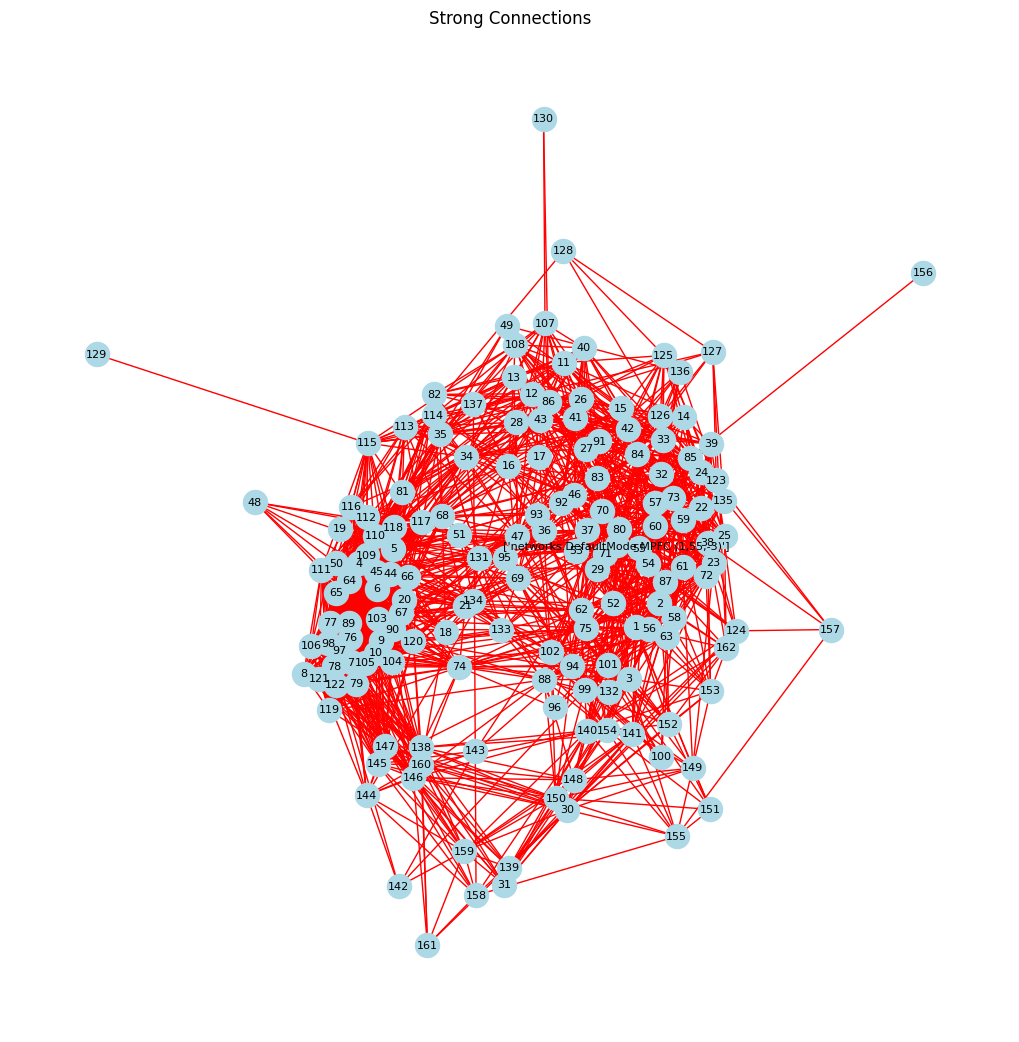

In [ ]:
# Filter edges with high weights
threshold = 0.7 # Adjust threshold
strong_edges = [(u, v) for u, v, weight in G.edges(data='weight') if weight and weight > threshold]

# Create a subgraph
subgraph = G.edge_subgraph(strong_edges)

# Visualize
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(subgraph, pos, with_labels=True, node_color='lightblue', edge_color='red', font_size=8, node_size=300)
plt.title("Strong Connections")
plt.show()


In [ ]:
import scipy.stats as stats

# Degree Distribution Comparison
healthy_degrees = [deg for _, deg in healthy_graph.degree()]
patient_degrees = [deg for _, deg in G.degree()]

# Statistical Test
t_stat, p_value = stats.ttest_ind(healthy_degrees, patient_degrees)
print(f"T-Statistic: {t_stat}, P-Value: {p_value}")

if p_value < 0.05:
    print("Significant difference in degree distribution between healthy and patient networks.")
else:
    print("No significant difference in degree distribution.")


T-Statistic: -0.47253011093421254, P-Value: 0.6368646328164893
No significant difference in degree distribution.


/usr/local/lib/python3.11/dist-packages/networkx/drawing/nx_pylab.py:457: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


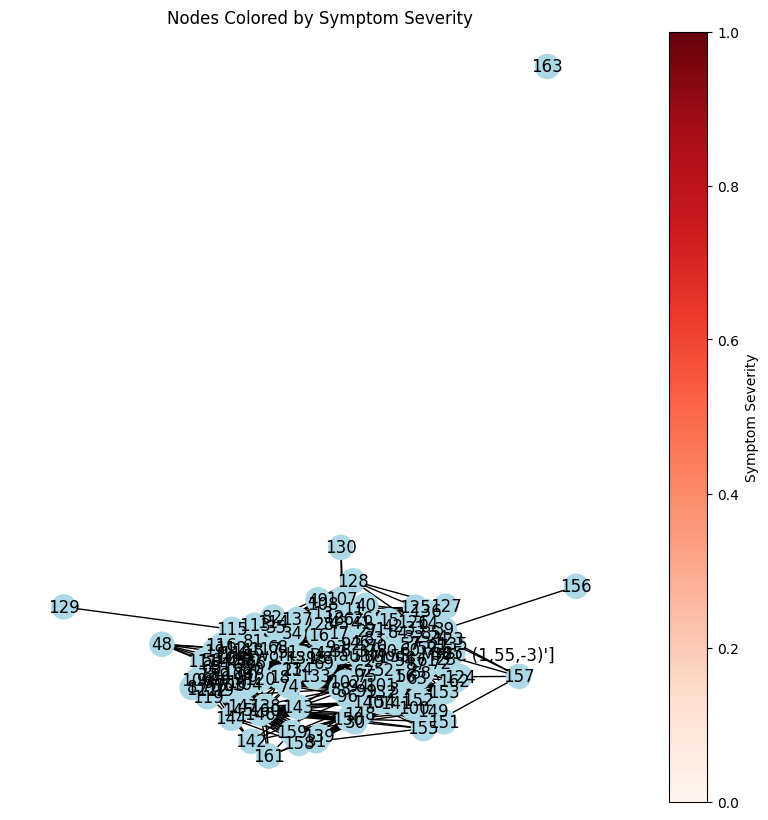

In [ ]:
# Example: Map symptom severity to nodes
symptom_scores = {roi_names[0, i][0]: np.random.rand() for i in range(len(roi_names[0]))}  # Replace with actual data

# Node coloring by symptom severity
node_colors = [symptom_scores.get(node, 'lightblue') for node in G.nodes()]  # Use .get() to handle missing keys
fig, ax = plt.subplots(figsize=(10, 10)) # Create a figure and axes object
nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.Reds, node_size=300, ax=ax) # Pass the axes object to nx.draw()
plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.Reds), label='Symptom Severity', ax=ax) # Pass the axes object to colorbar
plt.title("Nodes Colored by Symptom Severity")
plt.show()